# Portfolio Allocation vs. IPS Targets — Q1 2026

This report compares the current portfolio allocation to the Investment Policy Statement (IPS) targets as of Q1 2026. It answers three questions:

1. How is the portfolio currently allocated by asset class?
2. Which sleeves are above or below their IPS target weights?
3. Which asset classes are outside their IPS rebalance bands and may need action?

The analysis rolls fund-level positions up to asset-class weights using market value, then compares those weights to the IPS target, minimum, maximum, and rebalance-band rules.

## Configuration

Change these values to adjust the reporting date and rebalance sensitivity, then re-run the notebook from this point downward. The default view is Q1 2026.

In [3]:
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

positions_config_df = pd.read_csv('portfolio_positions.csv')
available_as_of_dates = sorted(positions_config_df['as_of_date'].unique())

as_of_date_widget = widgets.Dropdown(
    options=available_as_of_dates,
    value='2026-03-31',
    description='As-of date',
    style={'description_width': 'initial'},
    tooltip='Portfolio position date used for the allocation comparison.'
)

rebalance_band_multiplier_widget = widgets.FloatSlider(
    value=1.0,
    min=0.5,
    max=2.0,
    step=0.1,
    description='Rebalance band multiplier (x)',
    style={'description_width': 'initial'},
    tooltip='Multiplies each IPS rebalance band. 1.0 uses the IPS bands exactly as written.'
)

config_panel = widgets.VBox([
    widgets.HTML('<b>Report inputs</b>'),
    as_of_date_widget,
    rebalance_band_multiplier_widget
])

display(config_panel)

In [33]:
positions_raw_df = pd.read_csv('portfolio_positions.csv')
ips_df = pd.read_csv('ips_targets.csv')

positions_raw_df['as_of_date'] = pd.to_datetime(positions_raw_df['as_of_date'])
selected_as_of_date = pd.to_datetime(as_of_date_widget.value)
positions_df = positions_raw_df.loc[
    positions_raw_df['as_of_date'].eq(selected_as_of_date)
].copy()

total_aum = positions_df['market_value_usd'].sum()
current_allocation_df = (
    positions_df.groupby('asset_class', as_index=False)['market_value_usd']
    .sum()
    .assign(current_weight_pct=lambda d: d['market_value_usd'] / total_aum * 100)
    .sort_values('current_weight_pct', ascending=False)
)

In [34]:
ips_adjusted_df = ips_df.copy()
ips_adjusted_df['effective_rebalance_band_pct'] = (
    ips_adjusted_df['rebalance_band_pct'] * rebalance_band_multiplier_widget.value
)

allocation_vs_ips_df = current_allocation_df.merge(ips_adjusted_df, on='asset_class', how='left')
allocation_vs_ips_df['drift_from_target_pct'] = (
    allocation_vs_ips_df['current_weight_pct'] - allocation_vs_ips_df['target_weight_pct']
)
allocation_vs_ips_df['outside_band'] = (
    (allocation_vs_ips_df['drift_from_target_pct'].abs() > allocation_vs_ips_df['effective_rebalance_band_pct'])
    | (allocation_vs_ips_df['current_weight_pct'] < allocation_vs_ips_df['min_weight_pct'])
    | (allocation_vs_ips_df['current_weight_pct'] > allocation_vs_ips_df['max_weight_pct'])
)
allocation_vs_ips_df['status'] = allocation_vs_ips_df['outside_band'].map({True: 'Review', False: 'In range'})
allocation_vs_ips_df['market_value_usd_millions'] = allocation_vs_ips_df['market_value_usd'] / 1_000_000
allocation_vs_ips_df = allocation_vs_ips_df.sort_values('drift_from_target_pct', ascending=False)

## Executive summary

The tiles below summarize the portfolio's current size, how many asset classes need review, and where the largest allocation drifts sit versus IPS targets.

In [35]:
from IPython.display import HTML

review_count = int(allocation_vs_ips_df['outside_band'].sum())
largest_overweight_row = allocation_vs_ips_df.loc[allocation_vs_ips_df['drift_from_target_pct'].idxmax()]
largest_underweight_row = allocation_vs_ips_df.loc[allocation_vs_ips_df['drift_from_target_pct'].idxmin()]

summary_html = f"""
<div style="display: grid; grid-template-columns: repeat(4, 1fr); gap: 12px; margin: 8px 0 18px 0; font-family: Inter, Arial, sans-serif;">
  <div style="border: 1px solid #E0E0E0; border-radius: 8px; padding: 16px; background: #FFFFFF;">
    <div style="font-size: 28px; color: #1A1A24; font-variant-numeric: tabular-nums;">${total_aum / 1_000_000:,.0f}M</div>
    <div style="font-size: 13px; color: #6B6B78;">Total AUM</div>
  </div>
  <div style="border: 1px solid #E0E0E0; border-radius: 8px; padding: 16px; background: #FFFFFF;">
    <div style="font-size: 28px; color: #4C1D95; font-variant-numeric: tabular-nums;">{review_count}</div>
    <div style="font-size: 13px; color: #6B6B78;">Asset classes to review</div>
  </div>
  <div style="border: 1px solid #E0E0E0; border-radius: 8px; padding: 16px; background: #FFFFFF;">
    <div style="font-size: 28px; color: #1A1A24; font-variant-numeric: tabular-nums;">{largest_overweight_row['asset_class']}</div>
    <div style="font-size: 13px; color: #6B6B78;">Largest overweight: {largest_overweight_row['drift_from_target_pct']:+.1f} pts</div>
  </div>
  <div style="border: 1px solid #E0E0E0; border-radius: 8px; padding: 16px; background: #FFFFFF;">
    <div style="font-size: 28px; color: #1A1A24; font-variant-numeric: tabular-nums;">{largest_underweight_row['asset_class']}</div>
    <div style="font-size: 13px; color: #6B6B78;">Largest underweight: {largest_underweight_row['drift_from_target_pct']:+.1f} pts</div>
  </div>
</div>
"""

HTML(summary_html)

### What stands out

The short narrative below calls out the main allocation gaps for the selected reporting date.

In [36]:
review_asset_classes = allocation_vs_ips_df.loc[
    allocation_vs_ips_df['outside_band'], 'asset_class'
].tolist()
review_list_text = ', '.join(review_asset_classes)

narrative_html = f"""
<div style="border: 1px solid #E0E0E0; border-radius: 8px; padding: 16px; background: #FFFFFF; font-family: Inter, Arial, sans-serif; margin-bottom: 18px;">
  <div style="font-size: 18px; color: #1A1A24; margin-bottom: 8px;">{review_count} asset classes are outside IPS bands.</div>
  <div style="font-size: 14px; line-height: 1.55; color: #1A1A24;">
    {largest_overweight_row['asset_class']} is the largest overweight at {largest_overweight_row['drift_from_target_pct']:+.1f} percentage points versus target.
    {largest_underweight_row['asset_class']} is the largest underweight at {largest_underweight_row['drift_from_target_pct']:+.1f} percentage points versus target.
    The asset classes flagged for review are: {review_list_text}.
  </div>
  <div style="font-size: 12px; color: #6B6B78; margin-top: 10px;">From: portfolio_positions.csv and ips_targets.csv</div>
</div>
"""

HTML(narrative_html)

## Allocation by asset class versus IPS target

This chart compares each asset class's current portfolio weight against its IPS target. Bars above the target indicate overweights; bars below the target indicate underweights.

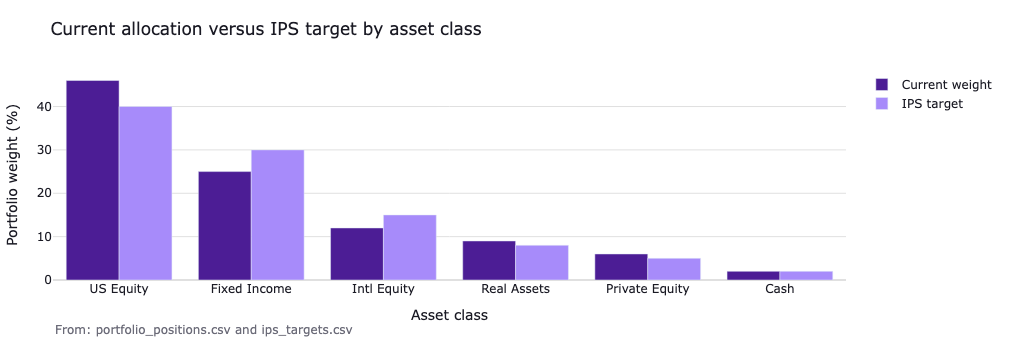

In [37]:
import plotly.graph_objects as go

chart_df = allocation_vs_ips_df.sort_values('target_weight_pct', ascending=False)

fig = go.Figure()
fig.add_trace(go.Bar(
    x=chart_df['asset_class'],
    y=chart_df['current_weight_pct'],
    name='Current weight',
    marker_color='#4C1D95',
    hovertemplate='<b>%{x}</b><br>Current weight: %{y:.1f}%<extra></extra>'
))
fig.add_trace(go.Bar(
    x=chart_df['asset_class'],
    y=chart_df['target_weight_pct'],
    name='IPS target',
    marker_color='#A78BFA',
    hovertemplate='<b>%{x}</b><br>IPS target: %{y:.1f}%<extra></extra>'
))

fig.update_layout(
    title='Current allocation versus IPS target by asset class',
    xaxis_title='Asset class',
    yaxis_title='Portfolio weight (%)',
    barmode='group',
    plot_bgcolor='#FFFFFF',
    paper_bgcolor='#FFFFFF',
    font=dict(color='#1A1A24'),
    legend_title_text='',
    margin=dict(l=40, r=20, t=70, b=80),
    annotations=[dict(
        text='From: portfolio_positions.csv and ips_targets.csv',
        xref='paper',
        yref='paper',
        x=0,
        y=-0.28,
        showarrow=False,
        font=dict(size=12, color='#6B6B78'),
        xanchor='left'
    )]
)
fig.update_yaxes(gridcolor='#E0E0E0', zerolinecolor='#E0E0E0')
fig.update_xaxes(showgrid=False)

fig

## Full allocation detail

The table below shows every asset class in the portfolio, including current weight, IPS target, drift, policy range, and review status. This is the complete allocation comparison behind the summary tiles and chart.

In [38]:
full_allocation_table_df = allocation_vs_ips_df[[
    'asset_class',
    'market_value_usd_millions',
    'current_weight_pct',
    'target_weight_pct',
    'drift_from_target_pct',
    'min_weight_pct',
    'max_weight_pct',
    'effective_rebalance_band_pct',
    'status'
]].copy()

full_allocation_table_df = full_allocation_table_df.rename(columns={
    'asset_class': 'Asset class',
    'market_value_usd_millions': 'Market value ($M)',
    'current_weight_pct': 'Current weight (%)',
    'target_weight_pct': 'IPS target (%)',
    'drift_from_target_pct': 'Drift from target (pts)',
    'min_weight_pct': 'IPS min (%)',
    'max_weight_pct': 'IPS max (%)',
    'effective_rebalance_band_pct': 'Effective rebalance band (pts)',
    'status': 'Status'
})

full_allocation_table_df

,Asset class,Market value ($M),Current weight (%),IPS target (%),Drift from target (pts),IPS min (%),IPS max (%),Effective rebalance band (pts),Status
0,US Equity,92.0,46.0,40.0,6.0,35.0,45.0,3.0,Review
3,Real Assets,18.0,9.0,8.0,1.0,5.0,12.0,2.0,In range
4,Private Equity,12.0,6.0,5.0,1.0,0.0,8.0,2.0,In range
5,Cash,4.0,2.0,2.0,0.0,0.0,5.0,1.0,In range
2,Intl Equity,24.0,12.0,15.0,-3.0,12.0,18.0,2.0,Review
1,Fixed Income,50.0,25.0,30.0,-5.0,25.0,35.0,3.0,Review


## Asset classes outside IPS bands

The table below shows the asset classes that require review under the IPS rules. A sleeve is flagged when it is outside its rebalance band or breaches the IPS minimum/maximum range.

In [39]:
review_table_df = allocation_vs_ips_df.loc[
    allocation_vs_ips_df['outside_band'],
    [
        'asset_class',
        'market_value_usd_millions',
        'current_weight_pct',
        'target_weight_pct',
        'drift_from_target_pct',
        'min_weight_pct',
        'max_weight_pct',
        'effective_rebalance_band_pct',
        'status'
    ]
].copy()

review_table_df = review_table_df.rename(columns={
    'asset_class': 'Asset class',
    'market_value_usd_millions': 'Market value ($M)',
    'current_weight_pct': 'Current weight (%)',
    'target_weight_pct': 'IPS target (%)',
    'drift_from_target_pct': 'Drift from target (pts)',
    'min_weight_pct': 'IPS min (%)',
    'max_weight_pct': 'IPS max (%)',
    'effective_rebalance_band_pct': 'Effective rebalance band (pts)',
    'status': 'Status'
})

review_table_df

,Asset class,Market value ($M),Current weight (%),IPS target (%),Drift from target (pts),IPS min (%),IPS max (%),Effective rebalance band (pts),Status
0,US Equity,92.0,46.0,40.0,6.0,35.0,45.0,3.0,Review
2,Intl Equity,24.0,12.0,15.0,-3.0,12.0,18.0,2.0,Review
1,Fixed Income,50.0,25.0,30.0,-5.0,25.0,35.0,3.0,Review


## How this was computed

<details>
<summary>Methodology and data sources</summary>

**Data sources**

- `portfolio_positions.csv`: fund-level positions, asset class, market value, and as-of date.
- `ips_targets.csv`: IPS target weight, minimum weight, maximum weight, and rebalance band by asset class.

**Calculation approach**

1. Filter positions to the selected as-of date in the Configuration panel.
2. Roll fund-level positions up to asset-class market value.
3. Calculate current asset-class weight as asset-class market value divided by total AUM.
4. Compare current weight to the IPS target weight.
5. Flag an asset class for review if either condition is true:
   - Absolute drift from target is greater than the effective rebalance band.
   - Current weight is below the IPS minimum or above the IPS maximum.

**Core formulas**

```python
current_weight_pct = asset_class_market_value / total_aum * 100
drift_from_target_pct = current_weight_pct - target_weight_pct
outside_band = (
    abs(drift_from_target_pct) > effective_rebalance_band_pct
    or current_weight_pct < min_weight_pct
    or current_weight_pct > max_weight_pct
)
```

Open this notebook in Jupyter to inspect or modify the generated Python code.

</details>